# Baseline Tests

Baseline plots for `bind=31`, `epsind=9`. Run before and after refactoring to verify no physics changes.

**Prerequisites:** From repo root:
```bash
conda activate pmhd
pip install -e .
python src/pmhd/physics/TCR_Tfs.py 31 0
python src/pmhd/physics/TCR_Tfs.py 31 20
python src/pmhd/physics/TCR_Tfs.py 31 40
python src/pmhd/physics/TCR_Tfs.py 31 68
```

In [165]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

REPO = Path("__file__").resolve().parents[1]
sys.path.insert(0, str(REPO / "src"))

from pmhd import cons, pars
from pmhd.data.grids import (
    k_grid, theta_grid, z_grid, eps_grid,
    load_or_generate_z_arrays,
    load_or_generate_B0arr,
)

karr       = k_grid()
thetaarr   = theta_grid()
zarr       = z_grid()
B0arr      = load_or_generate_B0arr()
epsarr     = eps_grid()
zcrossarr, zfsarr = load_or_generate_z_arrays()

OUTBASE = REPO / "data/outputs"

bind     = 30
epsind   = 9
Bdir     = OUTBASE / f"Tfs/B_{round(1e12*B0arr[bind])}pG"

kinds      = [0, 20, 40, 68]
thetainds  = [0, 8, 16]       # theta = 0, pi/4, pi/2

print(f"bind={bind}  B0 = {round(1e12*B0arr[bind])} pG")
print(f"epsind={epsind}")
print(f"kinds={kinds},  thetainds={thetainds}")

bind=30  B0 = 315 pG
epsind=9
kinds=[0, 20, 40, 68],  thetainds=[0, 8, 16]


## 1. TCR Alfvén transfer functions

`TCRalf[thetaind, component, z_index]`  
Components: 0 = δ, 1 = Θ

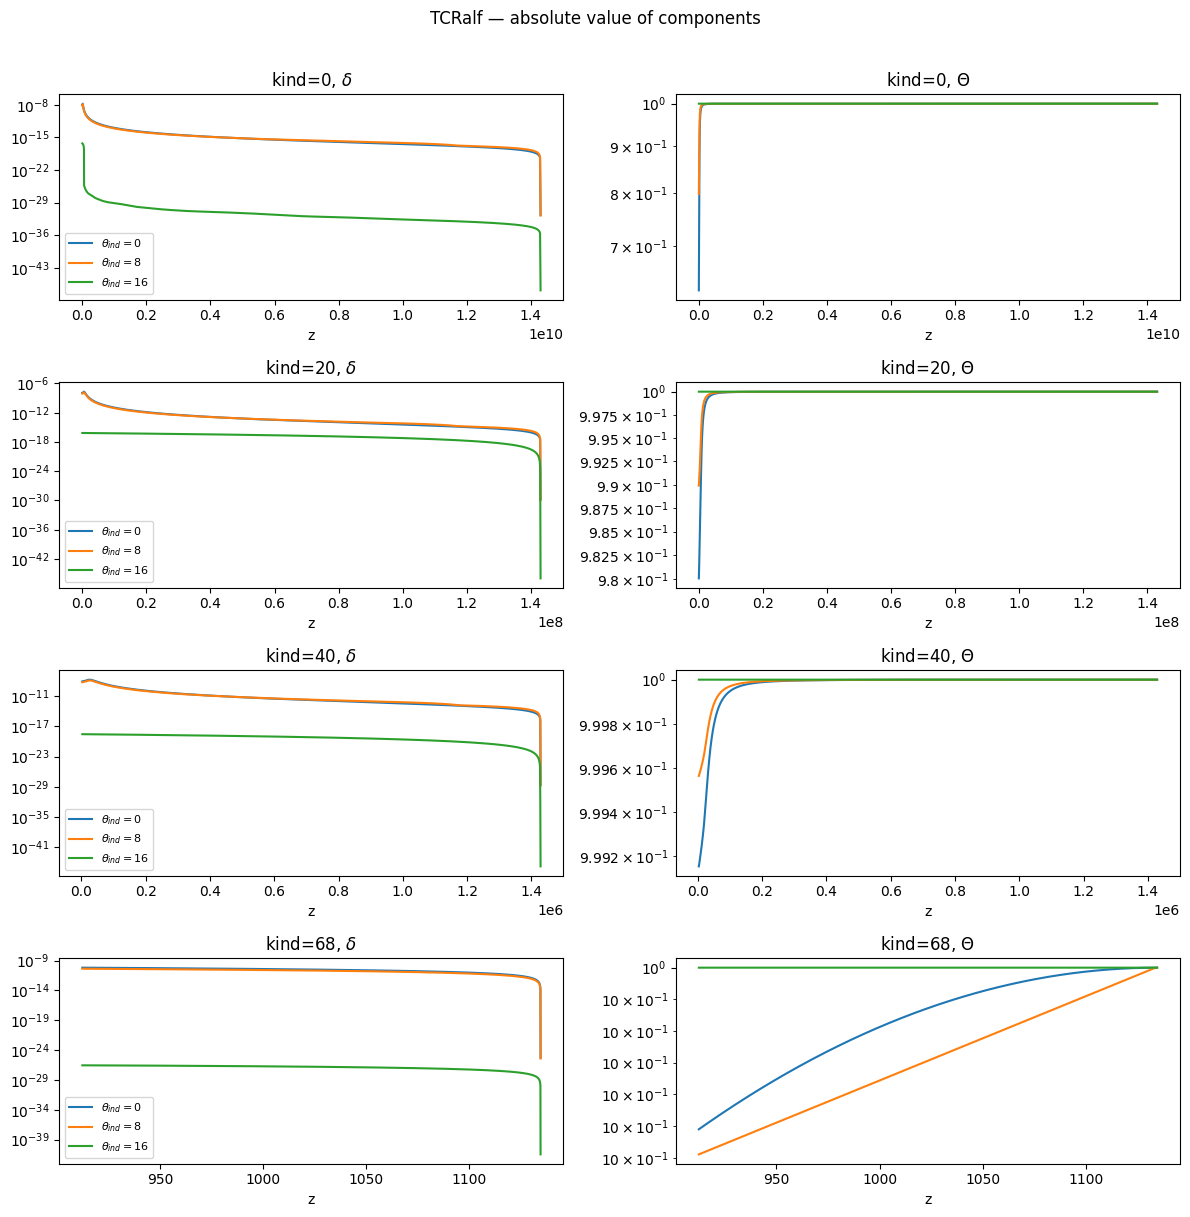

In [166]:
comp_labels_alf = [r'$\delta$', r'$\Theta$']
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(len(kinds), 2, figsize=(12, 3*len(kinds)), sharex='row')

for ki, kind in enumerate(kinds):
    TCRalf = np.load(Bdir / f"TCRalf_k{kind}.npy")
    zplot  = np.logspace(np.log10(zcrossarr[kind]), np.log10(zfsarr[kind]), 10**4)

    for comp in range(2):
        ax = axes[ki, comp]
        for ti, thetaind in enumerate(thetainds):
            ax.semilogy(zplot, np.abs(TCRalf[thetaind, comp, :]),
                        color=colors[ti],
                        label=rf'$\theta_{{ind}}={thetaind}$')
        ax.set_title(f'kind={kind}, {comp_labels_alf[comp]}')
        ax.set_xlabel('z')
        if comp == 0:
            ax.legend(fontsize=8)

fig.suptitle('TCRalf — absolute value of components', y=1.01)
plt.tight_layout()
plt.show()

## 2. TCR Magnetic transfer functions

`TCRmag[thetaind, component, z_index]`  
Components: 0 = δ, 1 = Θ, 2 = Φ, 3 = b

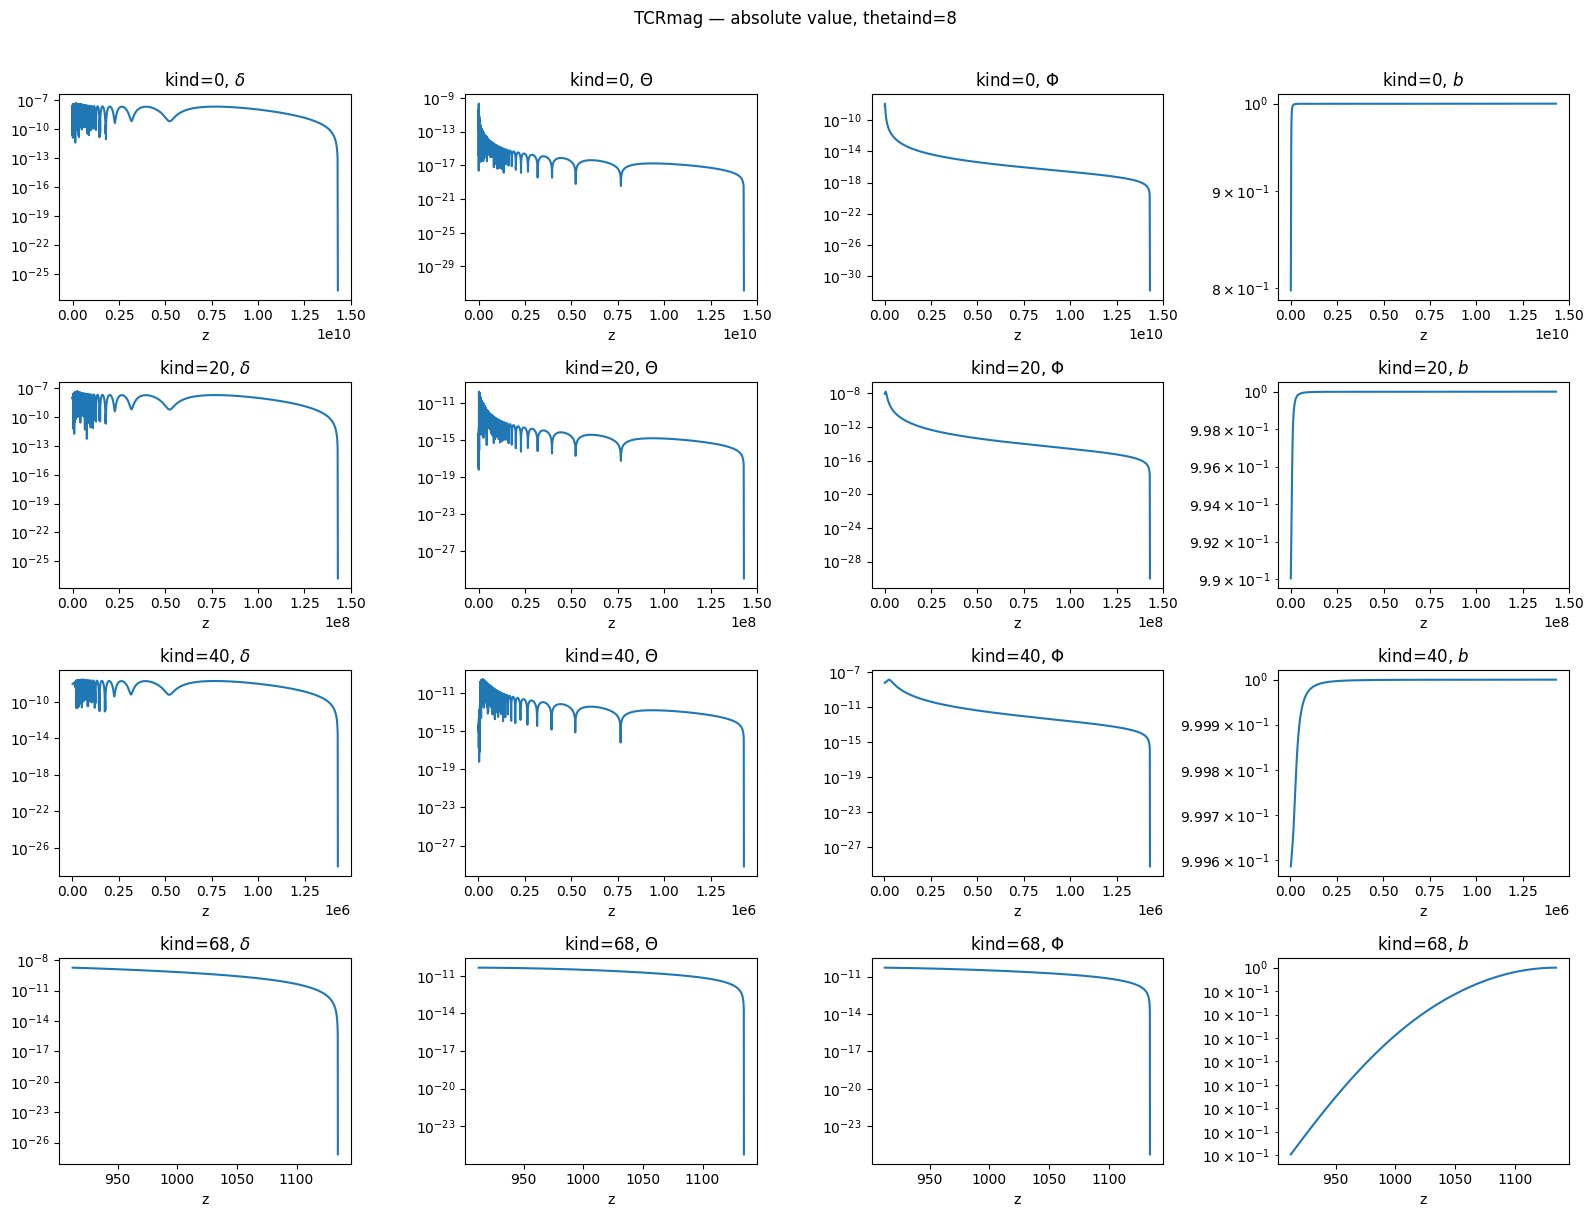

In [151]:
comp_labels_mag = [r'$\delta$', r'$\Theta$', r'$\Phi$', r'$b$']

fig, axes = plt.subplots(len(kinds), 4, figsize=(16, 3*len(kinds)), sharex='row')

thetaind_plot = 8   # fixed theta for this plot (theta = pi/4)

for ki, kind in enumerate(kinds):
    TCRmag = np.load(Bdir / f"TCRmag_k{kind}.npy")
    zplot  = np.logspace(np.log10(zcrossarr[kind]), np.log10(zfsarr[kind]), 10**4)

    for comp in range(4):
        ax = axes[ki, comp]
        ax.semilogy(zplot, np.abs(TCRmag[thetaind_plot, comp, :]), 'C0')
        ax.set_title(f'kind={kind}, {comp_labels_mag[comp]}')
        ax.set_xlabel('z')

fig.suptitle(f'TCRmag — absolute value, thetaind={thetaind_plot}', y=1.01)
plt.tight_layout()
plt.show()

## 3. Final b-field value at free-streaming transition

`TCRmag[:, 3, -1]` — the b component at `z = zfsarr[kind]`, for all thetaind.  
This is `diffmag_Tf_b` used downstream.

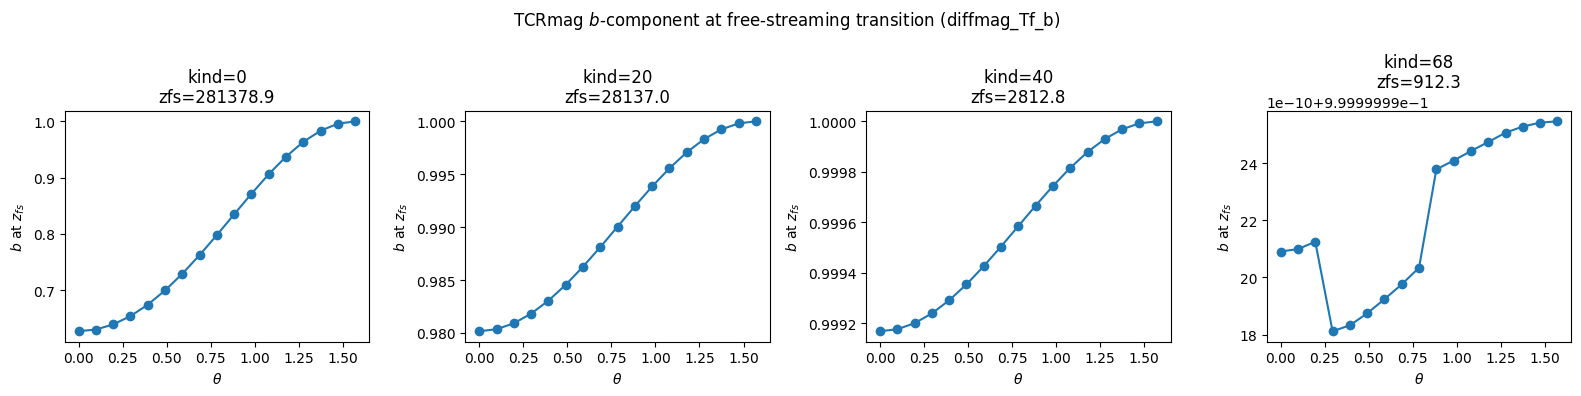

In [152]:
fig, axes = plt.subplots(1, len(kinds), figsize=(4*len(kinds), 4))

for ki, kind in enumerate(kinds):
    TCRmag = np.load(Bdir / f"TCRmag_k{kind}.npy")
    b_final = TCRmag[:, 3, -1]   # shape (17,)

    ax = axes[ki]
    ax.plot(thetaarr, b_final, 'o-')
    ax.set_title(f'kind={kind}\nzfs={zfsarr[kind]:.1f}')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$b$ at $z_{fs}$')

fig.suptitle(r'TCRmag $b$-component at free-streaming transition (diffmag_Tf_b)')
plt.tight_layout()
plt.show()

## 4. Matter power spectrum Δ²_δb(k) — TLA vs Saha

Assembles `deltamdeltambar(k, z)` from per-kind pickle files for bind=31.  
Plots `-ε (Λ/2π)^ε k^ε |<δ²>|(k)` at several redshifts between z=1500 and z=1000, solid = TLA, dotted = Saha.

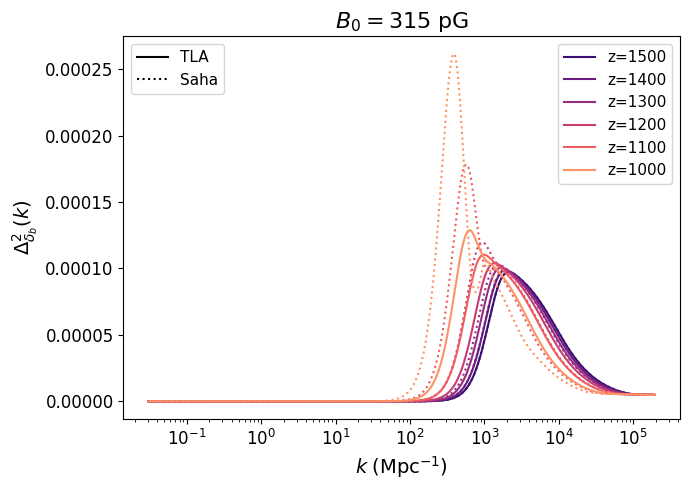

In [167]:
import pickle
from scipy.interpolate import splrep, splev
from matplotlib.lines import Line2D

# --- Assemble deltamdeltambar for bind=31 ---
bind = 30
deltamdeltambar     = np.zeros((len(karr), len(zarr)))
deltamdeltambar_saha = np.zeros((len(karr), len(zarr)))

ang_avg_TLA_dir  = OUTBASE / f"ang_avg/TLA/B_{round(1e12*B0arr[bind])}pG"
ang_avg_saha_dir = OUTBASE / f"ang_avg/saha/B_{round(1e12*B0arr[bind])}pG"

for kind in range(len(karr)):
    with open(ang_avg_TLA_dir  / f'ang_avg_k{kind}.pkl', 'rb') as f:
        deltamdeltambar[kind, :] = pickle.load(f)['deltamdeltambar']
    with open(ang_avg_saha_dir / f'ang_avg_k{kind}.pkl', 'rb') as f:
        deltamdeltambar_saha[kind, :] = pickle.load(f)['deltamdeltambar']

# --- Plot parameters ---
Lambda   = 1e3 * cons.mpc
epsind   = 9
eps      = epsarr[epsind]

karrfine = np.logspace(np.log10(karr.min()), np.log10(karr.max()), 500)

zindarr = np.arange(np.argwhere(zarr == 1500).item(),
                    np.argwhere(zarr == 1000).item() + 1, 100)
nz = len(zindarr)
nz = 8
colors_z = [plt.cm.magma(i) for i in np.linspace(0.2, 1, nz)]

fig, ax = plt.subplots(figsize=(7, 5))

for zi, zind in enumerate(zindarr):
    integrand_TLA = (-eps * (Lambda / 2 * np.pi)**eps
                     * (karrfine * cons.mpc)**eps
                     * np.abs(splev(karrfine * cons.mpc,
                                    splrep(karr[::-1] * cons.mpc,
                                           deltamdeltambar[::-1, zind]))))
    integrand_saha = (-eps * (Lambda / 2 * np.pi)**eps
                      * (karrfine * cons.mpc)**eps
                      * np.abs(splev(karrfine * cons.mpc,
                                     splrep(karr[::-1] * cons.mpc,
                                            deltamdeltambar_saha[::-1, zind]))))
    ax.semilogx(karrfine * cons.mpc, integrand_TLA,
                color=colors_z[zi], label=f'z={zarr[zind]:.0f}')
    ax.semilogx(karrfine * cons.mpc, integrand_saha,
                color=colors_z[zi], linestyle=':')

ax.set_xlabel(r'$k \; (\mathrm{Mpc}^{-1})$', fontsize=14)
ax.set_ylabel(r'$\Delta^2_{\delta_b}(k)$', fontsize=14)
ax.set_title(f'$B_0 = {round(1e12*B0arr[bind])}$ pG', fontsize=16)
ax.tick_params(labelsize=12)

legend_z = ax.legend(loc='upper right', fontsize=11)
ax.add_artist(legend_z)
ax.legend(handles=[
    Line2D([0], [0], color='black', linestyle='-',  label='TLA'),
    Line2D([0], [0], color='black', linestyle=':', label='Saha'),
], loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Second-order ionization fraction Δx_e^(2)(z)

`xe2` is the second-order perturbation to the ionization fraction for bind=31, epsind=9.  
Also shows the background xe(z) for reference.

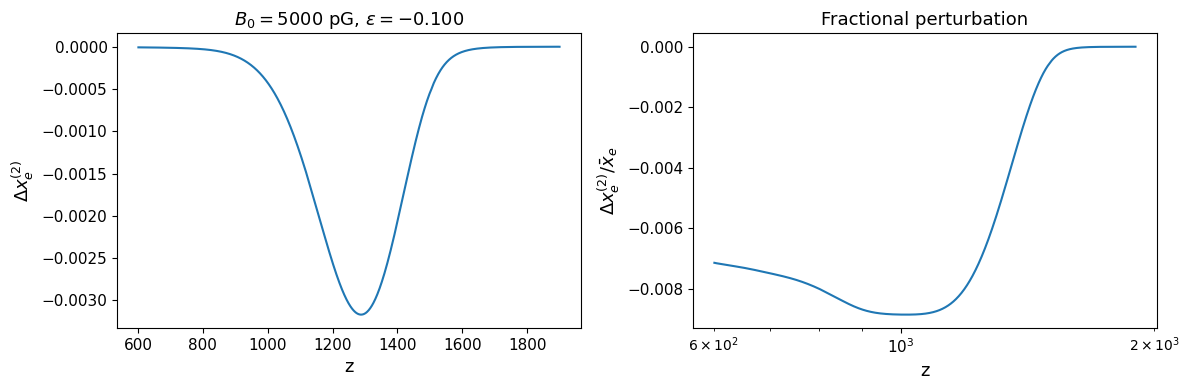

In [168]:
bind = 0;
xe2 = np.load(OUTBASE / f"xe2/xe2_B_{round(1e12*B0arr[bind])}pG_e{round(epsarr[epsind],3)}.npy")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: xe2 itself
axes[0].plot(zarr, (xe2))
axes[0].set_xlabel('z', fontsize=13)
axes[0].set_ylabel(r'$\Delta x_e^{(2)}$', fontsize=13)
axes[0].set_title(f'$B_0={round(1e12*B0arr[bind])}$ pG, $\\epsilon={epsarr[epsind]:.3f}$', fontsize=13)
axes[0].tick_params(labelsize=11)

# Right: xe2 / xe_background (fractional perturbation)
from scipy.interpolate import splrep, splev
from scipy.integrate import odeint
zstart = 2300
xesaha  = pars.sahataylor(np.arange(3e5, 2660, -1))
xesaha2 = pars.sahapol(np.arange(2660,200,-1))
xesaha_hold = splrep( np.flip(np.arange(3e5,200,-1)),np.flip(np.append(xesaha,xesaha2)) )

xepeebs = pars.odeint(pars.RHSsob, pars.sahataylor(zstart), np.arange(zstart, 200, -1))
xe_hold = splrep(
    np.flip(np.concatenate([np.linspace(1e11, 3.1e5, 10000), np.arange(3e5, 200, -1)])),
    np.flip(np.concatenate([np.ones(10000), np.append(xesaha,xesaha2)[:len(np.arange(3e5,zstart,-1))], xepeebs[:, 0]]))
)
xe_bg = splev(zarr, xe_hold)

def xe_full(z):
    return splev(z, xe_hold)

def xesaha_full(z):
    return splev(z, xesaha_hold) 

axes[1].semilogx(zarr, (xe2) / xe_bg)
axes[1].set_xlabel('z', fontsize=13)
axes[1].set_ylabel(r'$\Delta x_e^{(2)} / \bar{x}_e$', fontsize=13)
axes[1].set_title('Fractional perturbation', fontsize=13)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

## 6. Δx_e^(2) for all B values (epsind=9)

All computed bind values overlaid on a single plot, colored by B₀.

In [156]:
import pickle
from scipy.interpolate import splrep, splint

Lambda = 1e3 * cons.mpc
deltamrmssaha = np.zeros((len(zarr), len(B0arr), len(epsarr)))

for bind in range(0, len(B0arr), 10):
    # Load ang_avg data once per bind (not inside the z-loop)
    ang_avg_saha_dir = OUTBASE / f"ang_avg/saha/B_{round(1e12*B0arr[bind])}pG"
    deltamdeltambar_saha_b = np.zeros((len(karr), len(zarr)))
    for kind in range(len(karr)):
        with open(ang_avg_saha_dir / f'ang_avg_k{kind}.pkl', 'rb') as f:
            deltamdeltambar_saha_b[kind, :] = pickle.load(f)['deltamdeltambar']

    for ei in range(9, 10):
        for zind in range(len(zarr)):
            deltamrmssaha[zind, bind, ei] = (
                abs(epsarr[ei]) / 4
                * (Lambda / (2 * np.pi))**epsarr[ei]
                * splint(
                    karr[-1], karr[0],
                    splrep(
                        np.flip(karr),
                        np.flip(karr**(epsarr[ei] - 1) * deltamdeltambar_saha_b[:, zind])
                    )
                )
            )

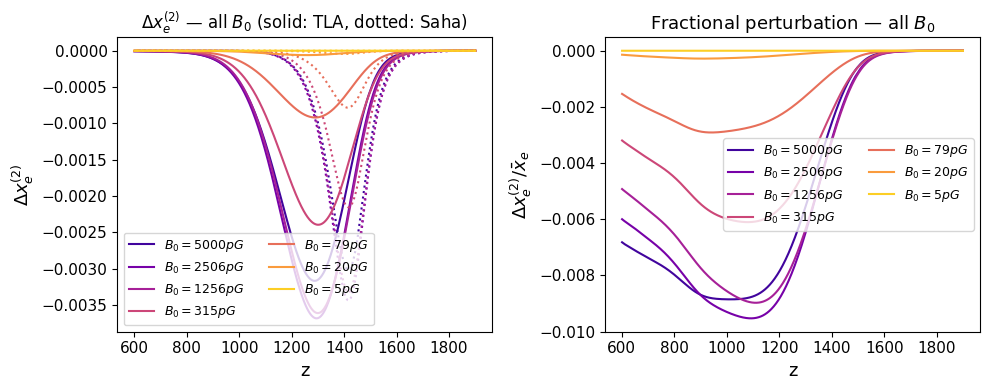

B values plotted:
  5000pG: max|xe2|=3.1670e-03
  2506pG: max|xe2|=3.6826e-03
  1256pG: max|xe2|=3.6104e-03
  315pG: max|xe2|=2.3949e-03
  79pG: max|xe2|=9.1911e-04
  20pG: max|xe2|=6.0520e-05
  5pG: max|xe2|=6.1099e-07


In [158]:
xe2_dir = OUTBASE / "xe2"
xe2_files = sorted(xe2_dir.glob(f"xe2_B_*pG_e{round(epsarr[epsind],3)}.npy"),
                   key=lambda p: int(p.stem.split('_B_')[1].split('pG')[0]),
                   reverse=True)

colors_b = [plt.cm.plasma(i) for i in np.linspace(0.1, 0.9, len(xe2_files))]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cmap = plt.get_cmap('tab10')


for i, fp in enumerate(xe2_files):
    B_str = fp.stem.split('_B_')[1].split('_e')[0]   # e.g. "5000pG"
    B_pg  = int(B_str.replace('pG', ''))
    bind_i = int(np.argmin(np.abs(np.round(1e12 * B0arr) - B_pg)))
    color = cmap(bind_i % 7)
    xe2_i   = np.load(fp)
    xesaha2 = (-xesaha_full(zarr) * deltamrmssaha[:, bind_i, epsind]
               * (1 - xesaha_full(zarr)) / (2 - xesaha_full(zarr))**3)

    label = f'$B_0={B_str}$'
    axes[0].plot(zarr, xe2_i,   color=colors_b[i], label=label)
    axes[0].plot(zarr, xesaha2, color=colors_b[i], linestyle=':')
    axes[1].plot(zarr, xe2_i / xe_bg, color=colors_b[i], label=label)

for ax in axes:
    ax.set_xlabel('z', fontsize=13)
    ax.legend(fontsize=9, ncol=2)
    ax.tick_params(labelsize=11)

axes[0].set_ylabel(r'$\Delta x_e^{(2)}$', fontsize=13)
axes[0].set_title(r'$\Delta x_e^{(2)}$ — all $B_0$ (solid: TLA, dotted: Saha)', fontsize=12)
axes[1].set_ylabel(r'$\Delta x_e^{(2)} / \bar{x}_e$', fontsize=13)
axes[1].set_title(r'Fractional perturbation — all $B_0$', fontsize=13)

plt.tight_layout()
plt.show()

print("B values plotted:")
for fp in xe2_files:
    xe2_i  = np.load(fp)
    B_str  = fp.stem.split('_B_')[1].split('_e')[0]
    print(f"  {B_str}: max|xe2|={np.max(np.abs(xe2_i)):.4e}")

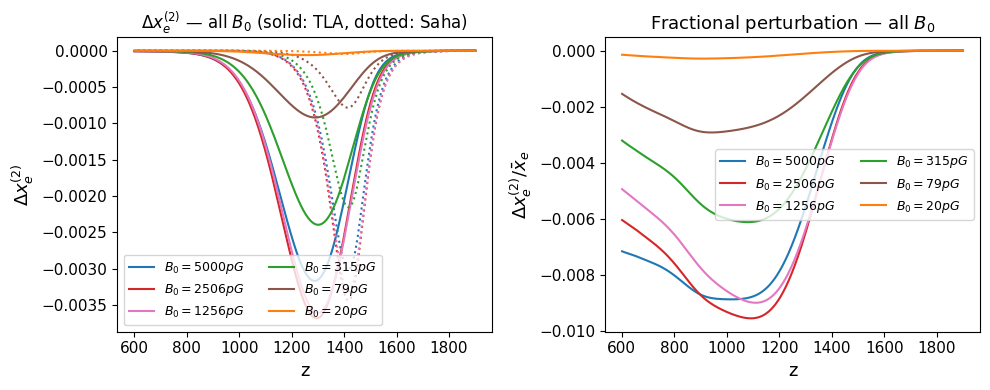

B values plotted:
  5000pG: max|xe2|=3.1671e-03
  2506pG: max|xe2|=3.6826e-03
  1256pG: max|xe2|=3.6104e-03
  315pG: max|xe2|=2.3949e-03
  79pG: max|xe2|=9.1910e-04
  20pG: max|xe2|=6.0520e-05


In [171]:
xe2_dir = OUTBASE / "xe2"
xe2_files = sorted(xe2_dir.glob(f"xe2_B_*pG_e{round(epsarr[epsind],3)}.npy"),
                   key=lambda p: int(p.stem.split('_B_')[1].split('pG')[0]),
                   reverse=True)[:6]

colors_b = [plt.cm.plasma(i) for i in np.linspace(0.1, 0.9, len(xe2_files))]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cmap = plt.get_cmap('tab10')


for i, fp in enumerate(xe2_files):
    B_str = fp.stem.split('_B_')[1].split('_e')[0]   # e.g. "5000pG"
    B_pg  = int(B_str.replace('pG', ''))
    bind_i = int(np.argmin(np.abs(np.round(1e12 * B0arr) - B_pg)))
    color = cmap(bind_i % 7)
    xe2_i   = np.load(fp)
    xesaha2 = (-xesaha_full(zarr) * deltamrmssaha[:, bind_i, epsind]
               * (1 - xesaha_full(zarr)) / (2 - xesaha_full(zarr))**3)

    label = f'$B_0={B_str}$'
    axes[0].plot(zarr, xe2_i,   color=color, label=label)
    axes[0].plot(zarr, xesaha2, color=color, linestyle=':')
    axes[1].plot(zarr, xe2_i / xe_bg, color=color, label=label)

for ax in axes:
    ax.set_xlabel('z', fontsize=13)
    ax.legend(fontsize=9, ncol=2)
    ax.tick_params(labelsize=11)

axes[0].set_ylabel(r'$\Delta x_e^{(2)}$', fontsize=13)
axes[0].set_title(r'$\Delta x_e^{(2)}$ — all $B_0$ (solid: TLA, dotted: Saha)', fontsize=12)
axes[1].set_ylabel(r'$\Delta x_e^{(2)} / \bar{x}_e$', fontsize=13)
axes[1].set_title(r'Fractional perturbation — all $B_0$', fontsize=13)

plt.tight_layout()
plt.show()

print("B values plotted:")
for fp in xe2_files:
    xe2_i  = np.load(fp)
    B_str  = fp.stem.split('_B_')[1].split('_e')[0]
    print(f"  {B_str}: max|xe2|={np.max(np.abs(xe2_i)):.4e}")

## 7. Visibility function peak shift — all B₀ (epsind=9)

For each sample B₀, computes the full perturbed visibility `g_tot(z) = g_bg(z) × visibprefactor(z)` and finds the peak redshift. The right panel shows the shift `Δz_peak = z_peak(B₀) − z_peak(background)`.

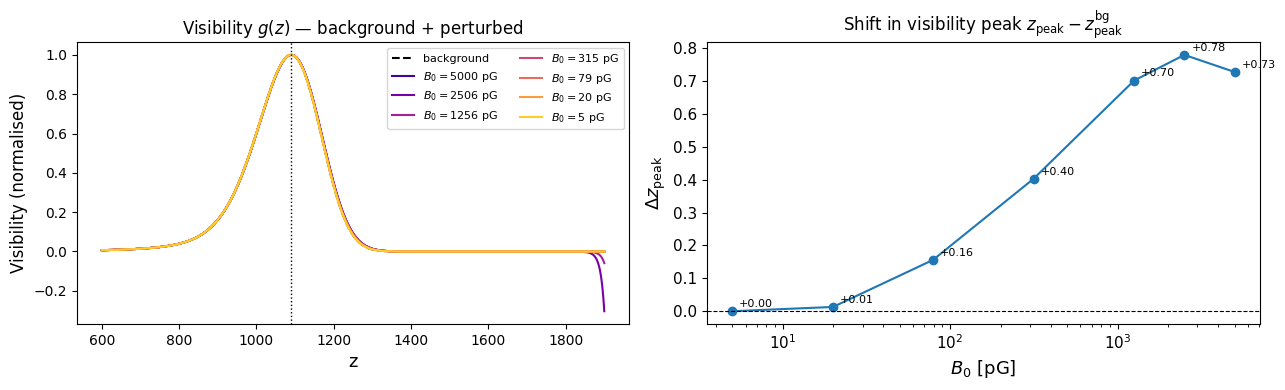

Background peak: z = 1089.53
  bind     B0 (pG)     zpeak     Dz_peak
------------------------------------------
     0        5000   1090.26     +0.7280
    10        2506   1090.31     +0.7800
    20        1256   1090.23     +0.7020
    30         315   1089.94     +0.4030
    40          79   1089.69     +0.1560
    50          20   1089.55     +0.0130
    60           5   1089.53     +0.0000


In [121]:
from scipy.interpolate import splrep, splev

# --- Background optical depth and visibility ---
tau0arr_bg = np.load(REPO / 'src/pmhd/data/pre_stored_data/tau0arr.npy')
dtaudz_bg  = pars.nh(zarr) * xe_full(zarr) * cons.sigmat / (1 + zarr)
visibarr   = dtaudz_bg * np.exp(tau0arr_bg)

# Fine z grid for peak-finding (600 → 1900)
zarrfine     = np.linspace(600, 1900, 100_000)
visib_bg_fine = splev(zarrfine, splrep(zarr[::-1], visibarr[::-1]))
zpeak_bg     = zarrfine[np.argmax(visib_bg_fine)]

# --- Load visibprefactor and compute perturbed visibility for each sample bind ---
sample_binds = [0, 10, 20, 30, 40, 50, 60]
eps_val      = round(epsarr[epsind], 3)

peakarr   = {}
relshift  = {}
visib_tot = {}

for bind_i in sample_binds:
    B_pg = round(1e12 * B0arr[bind_i])
    vpf  = np.load(OUTBASE / f'visib/visib_B_{B_pg}pG_e{eps_val}.npy')
    vtot = visibarr * vpf
    visib_tot[bind_i] = vtot
    fine = splev(zarrfine, splrep(zarr[::-1], vtot[::-1]))
    peakarr[bind_i]  = zarrfine[np.argmax(fine)]
    relshift[bind_i] = peakarr[bind_i] - zpeak_bg

# --- Plot ---
colors_b = [plt.cm.plasma(i) for i in np.linspace(0.1, 0.9, len(sample_binds))]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: visibility curves (normalised to peak)
axes[0].plot(zarrfine, visib_bg_fine / visib_bg_fine.max(),
             'k--', label='background', lw=1.5)
for i, bind_i in enumerate(sample_binds):
    fine = splev(zarrfine, splrep(zarr[::-1], visib_tot[bind_i][::-1]))
    axes[0].plot(zarrfine, fine / fine.max(),
                 color=colors_b[i], label=f'$B_0={round(1e12*B0arr[bind_i])}$ pG')
axes[0].axvline(zpeak_bg, color='k', linestyle=':', lw=1)
axes[0].set_xlabel('z', fontsize=13)
axes[0].set_ylabel('Visibility (normalised)', fontsize=12)
axes[0].set_title(r'Visibility $g(z)$ — background + perturbed', fontsize=12)
axes[0].legend(fontsize=8, ncol=2)

# Right: peak shift vs B0
B_vals = [round(1e12 * B0arr[b]) for b in sample_binds]
shifts = [relshift[b] for b in sample_binds]
axes[1].semilogx(B_vals, shifts, 'o-', color='C0')
for bv, sh in zip(B_vals, shifts):
    axes[1].annotate(f'{sh:+.2f}', (bv, sh), textcoords='offset points',
                     xytext=(5, 3), fontsize=8)
axes[1].axhline(0, color='k', linestyle='--', lw=0.8)
axes[1].set_xlabel(r'$B_0$ [pG]', fontsize=13)
axes[1].set_ylabel(r'$\Delta z_{\rm peak}$', fontsize=13)
axes[1].set_title(r'Shift in visibility peak $z_{\rm peak} - z_{\rm peak}^{\rm bg}$', fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# Summary table
print(f"Background peak: z = {zpeak_bg:.2f}")
print(f"{'bind':>6}  {'B0 (pG)':>10}  {'zpeak':>8}  {'Dz_peak':>10}")
print('-' * 42)
for bind_i in sample_binds:
    print(f"{bind_i:>6}  {round(1e12*B0arr[bind_i]):>10}  "
          f"{peakarr[bind_i]:>8.2f}  {relshift[bind_i]:>+10.4f}")

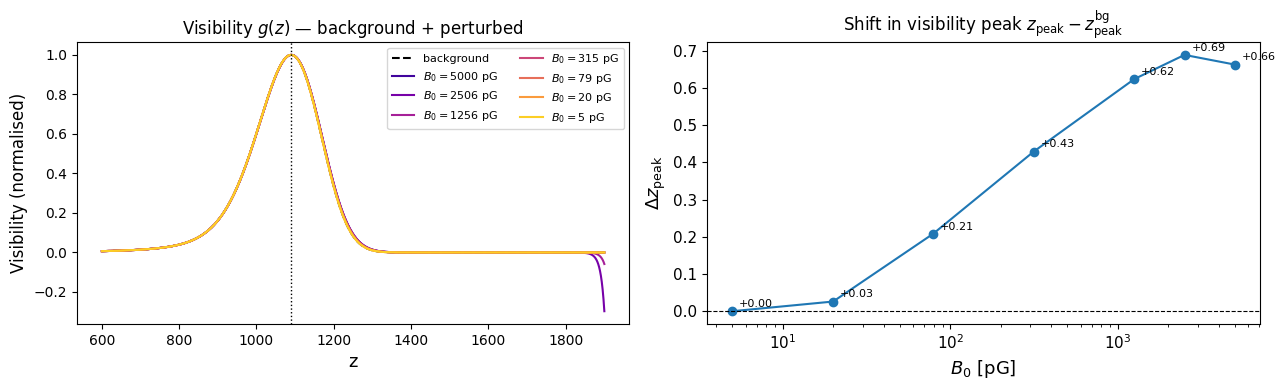

Background peak: z = 1089.53
  bind     B0 (pG)     zpeak     Dz_peak
------------------------------------------
     0        5000   1090.20     +0.6630
    10        2506   1090.22     +0.6890
    20        1256   1090.16     +0.6240
    30         315   1089.96     +0.4290
    40          79   1089.74     +0.2080
    50          20   1089.56     +0.0260
    60           5   1089.53     +0.0000


In [170]:
from scipy.interpolate import splrep, splev

# --- Background optical depth and visibility ---
tau0arr_bg = np.load(REPO / 'src/pmhd/data/pre_stored_data/tau0arr.npy')
dtaudz_bg  = pars.nh(zarr) * xe_full(zarr) * cons.sigmat / (1 + zarr)
visibarr   = dtaudz_bg * np.exp(tau0arr_bg)

# Fine z grid for peak-finding (600 → 1900)
zarrfine     = np.linspace(600, 1900, 100_000)
visib_bg_fine = splev(zarrfine, splrep(zarr[::-1], visibarr[::-1]))
zpeak_bg     = zarrfine[np.argmax(visib_bg_fine)]

# --- Load visibprefactor and compute perturbed visibility for each sample bind ---
sample_binds = [0, 10, 20, 30, 40, 50, 60]
eps_val      = round(epsarr[epsind], 3)

peakarr   = {}
relshift  = {}
visib_tot = {}

for bind_i in sample_binds:
    B_pg = round(1e12 * B0arr[bind_i])
    vpf  = np.load(OUTBASE / f'visib/visib_B_{B_pg}pG_e{eps_val}.npy')
    vtot = visibarr * vpf
    visib_tot[bind_i] = vtot
    fine = splev(zarrfine, splrep(zarr[::-1], vtot[::-1]))
    peakarr[bind_i]  = zarrfine[np.argmax(fine)]
    relshift[bind_i] = peakarr[bind_i] - zpeak_bg

# --- Plot ---
colors_b = [plt.cm.plasma(i) for i in np.linspace(0.1, 0.9, len(sample_binds))]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: visibility curves (normalised to peak)
axes[0].plot(zarrfine, visib_bg_fine / visib_bg_fine.max(),
             'k--', label='background', lw=1.5)
for i, bind_i in enumerate(sample_binds):
    fine = splev(zarrfine, splrep(zarr[::-1], visib_tot[bind_i][::-1]))
    axes[0].plot(zarrfine, fine / fine.max(),
                 color=colors_b[i], label=f'$B_0={round(1e12*B0arr[bind_i])}$ pG')
axes[0].axvline(zpeak_bg, color='k', linestyle=':', lw=1)
axes[0].set_xlabel('z', fontsize=13)
axes[0].set_ylabel('Visibility (normalised)', fontsize=12)
axes[0].set_title(r'Visibility $g(z)$ — background + perturbed', fontsize=12)
axes[0].legend(fontsize=8, ncol=2)

# Right: peak shift vs B0
B_vals = [round(1e12 * B0arr[b]) for b in sample_binds]
shifts = [relshift[b] for b in sample_binds]
axes[1].semilogx(B_vals, shifts, 'o-', color='C0')
for bv, sh in zip(B_vals, shifts):
    axes[1].annotate(f'{sh:+.2f}', (bv, sh), textcoords='offset points',
                     xytext=(5, 3), fontsize=8)
axes[1].axhline(0, color='k', linestyle='--', lw=0.8)
axes[1].set_xlabel(r'$B_0$ [pG]', fontsize=13)
axes[1].set_ylabel(r'$\Delta z_{\rm peak}$', fontsize=13)
axes[1].set_title(r'Shift in visibility peak $z_{\rm peak} - z_{\rm peak}^{\rm bg}$', fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# Summary table
print(f"Background peak: z = {zpeak_bg:.2f}")
print(f"{'bind':>6}  {'B0 (pG)':>10}  {'zpeak':>8}  {'Dz_peak':>10}")
print('-' * 42)
for bind_i in sample_binds:
    print(f"{bind_i:>6}  {round(1e12*B0arr[bind_i]):>10}  "
          f"{peakarr[bind_i]:>8.2f}  {relshift[bind_i]:>+10.4f}")

## 8. FSR Alfvén: log(z) vs z integration comparison (thetaind=7)

Validates that the log(z) variable change gives numerically identical results to the standard z integration for `kind=3, bind=56, thetaind=7` — the case adjacent to the pathological θ=45° mode.

In [ ]:
from scipy.integrate import solve_ivp

kind_fsr, bind_fsr, ti = 3, 56, 7
k    = karr[kind_fsr]
theta = thetaarr[ti]
B0   = B0arr[bind_fsr]
zstart = zfsarr[kind_fsr]

zgrid = np.logspace(np.log10(zstart), np.log10(600), 10**4)

# --- z integration (baseline) ---
sol_z = solve_ivp(pars.FSRsahaalf, [zstart, 600], [0, 1],
                  args=(k, theta, B0, pars.xesaha_full),
                  method='LSODA', dense_output=True, atol=1e-9, rtol=1e-6)
out_z = sol_z.sol(zgrid)

# --- log(z) integration ---
def rhs_logz(lz, v):
    z = np.exp(lz)
    dv = pars.FSRsahaalf(z, v, k, theta, B0, pars.xesaha_full)
    return [dv[0]*z, dv[1]*z]

lzgrid = np.log(zgrid)
sol_lz = solve_ivp(rhs_logz, [lzgrid[0], lzgrid[-1]], [0, 1],
                   method='LSODA', dense_output=True, atol=1e-9, rtol=1e-6)
out_lz = sol_lz.sol(lzgrid)

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for row, label in enumerate([r'$\Phi_x$', r'$b_x$']):
    ax = axes[row]
    ax.semilogx(zgrid, out_z[row],  'b-',  lw=1.5, label='z integration')
    ax.semilogx(zgrid, out_lz[row], 'r--', lw=1.5, label='log(z) integration')
    ax.set_ylabel(label, fontsize=13)
    ax.legend()
    ax.invert_xaxis()
    ax.set_title(f'{label}  (thetaind={ti}, kind={kind_fsr}, bind={bind_fsr})', fontsize=12)

for row, label in enumerate([r'$\Phi_x$', r'$b_x$']):
    denom = np.abs(out_z[row]) + 1e-30
    axes[2].loglog(zgrid, np.abs(out_z[row] - out_lz[row]) / denom, label=label)
axes[2].set_ylabel('|rel diff|', fontsize=13)
axes[2].set_xlabel('z', fontsize=13)
axes[2].legend()
axes[2].invert_xaxis()
axes[2].set_title('Relative difference (z vs log(z))', fontsize=12)

plt.tight_layout()
plt.show()

print(f"z:    ok={sol_z.success},  nfev={sol_z.nfev}")
print(f"logz: ok={sol_lz.success}, nfev={sol_lz.nfev}")